In [47]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score,f1_score, make_scorer, roc_curve, auc
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from catboost import CatBoostClassifier

data_path = "/Users/nika/Desktop/Tor/raw"
MY_IP = "192.168.0.74"
MAX_LEN = 2000

In [2]:
csv_files = glob.glob(os.path.join(data_path, "*.csv"))
print("Found files:", len(csv_files))

Found files: 80


In [3]:
def extract_features_summary(csv_file):
    df = pd.read_csv(csv_file, encoding="latin1", low_memory=False)
    df.columns = df.columns.str.lower()

    time_col = "time"
    size_col = "length"
    src_col = "source"

    df[time_col] = pd.to_datetime(df[time_col], format="%H:%M:%S.%f")
    df["time_seconds"] = (df[time_col] - df[time_col].iloc[0]).dt.total_seconds()

    packet_sizes = df[size_col].values
    inter_times = np.diff(df["time_seconds"].values)
    inter_times = np.insert(inter_times, 0, 0)

    direction = np.where(df[src_col] == MY_IP, 1, -1)
    
    bursts = []
    current = 1
    for i in range(1, len(direction)):
        if direction[i] == direction[i-1]:
            current += 1
        else:
            bursts.append(current)
            current = 1
    bursts.append(current)

    features = [
        len(df),
        np.mean(packet_sizes),
        np.std(packet_sizes),
        np.max(packet_sizes),
        np.min(packet_sizes),
        np.mean(inter_times),
        np.std(inter_times),
        np.mean(direction == 1),
        np.mean(bursts),
        np.max(bursts),
        np.min(bursts)
    ]

    return features

In [4]:
##Check all csvs
X = []
y = []
import re
for f in csv_files:
    try:
        X.append(extract_features_summary(f))
        label = os.path.basename(f).split(".")[0]
        y.append(label)
    except Exception as e:
        print("Error:", f, e)

dataset = pd.DataFrame(X)
dataset["label"] = y
dataset["label"] = dataset["label"].apply(lambda x: re.sub(r"\d+", "", x))

print(dataset.head())
print(dataset["label"].value_counts())

       0            1           2     3   4         5         6         7  \
0   6056   946.085535  600.871053  1494  42  0.004104  0.019377  0.306143   
1  12953   742.699838  559.739593  1514  42  0.002237  0.009621  0.000000   
2   8488  1135.007422  561.478936  1494  42  0.003286  0.025966  0.209708   
3   3590  1180.377437  536.209535  1474  42  0.006217  0.040886  0.174652   
4  10667   961.593044  503.580128  1514  42  0.001855  0.010207  0.000000   

              8      9     10    label  
0      2.840525     39      1  reuters  
1  12953.000000  12953  12953     ebay  
2      4.668867     55      1   github  
3      5.218023     49      1   github  
4  10667.000000  10667  10667  walmart  
label
reuters           5
ebay              5
github            5
walmart           5
hackaday          5
bloomberg         5
nytimes           5
medium            5
washingtonpost    5
theguardian       5
bbc               5
etsy              5
stackoverflow     5
cnn               5
amazo

In [5]:
##Saving dataset
output_path = os.path.join(
    os.path.dirname(data_path),
    "tor_features_dataset.csv"
)

dataset.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

Saved: /Users/nika/Desktop/Tor/tor_features_dataset.csv


In [6]:
##Train/Test split
X = dataset.drop("label", axis=1).values
y = dataset["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (64, 11)
Test: (16, 11)


In [18]:
##TRAIN ON CSV ONLYYYYYY
rf = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, average="weighted", zero_division=0),
    "recall": make_scorer(recall_score, average="weighted", zero_division=0),
    "f1": make_scorer(f1_score, average="weighted", zero_division=0)
}

cv_results = cross_validate(rf, X, y, cv=5, scoring=scoring)

print(f"Accuracy:  {cv_results['test_accuracy'].mean():.4f}")
print(f"Precision: {cv_results['test_precision'].mean():.4f}")
print(f"Recall:    {cv_results['test_recall'].mean():.4f}")
print(f"F1-score:  {cv_results['test_f1'].mean():.4f}")

Accuracy:  0.6375
Precision: 0.5208
Recall:    0.6375
F1-score:  0.5583


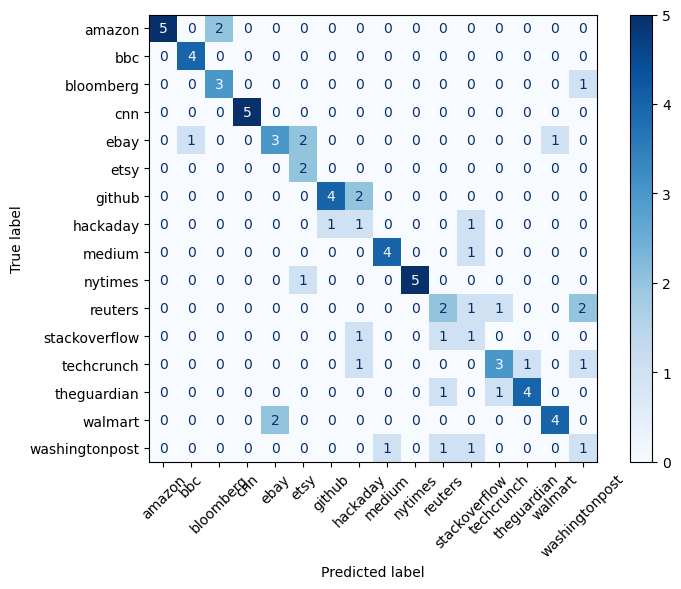

In [24]:
##Confusion matrix
y_pred_cv = cross_val_predict(rf, X, y, cv=5)

cm = confusion_matrix(y_pred_cv, y, labels=np.unique(y))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(xticks_rotation=45, cmap="Blues", ax=ax)
plt.tight_layout()
plt.savefig("confusion_matrix_rf_csv.png", dpi=300, bbox_inches='tight')
plt.show()

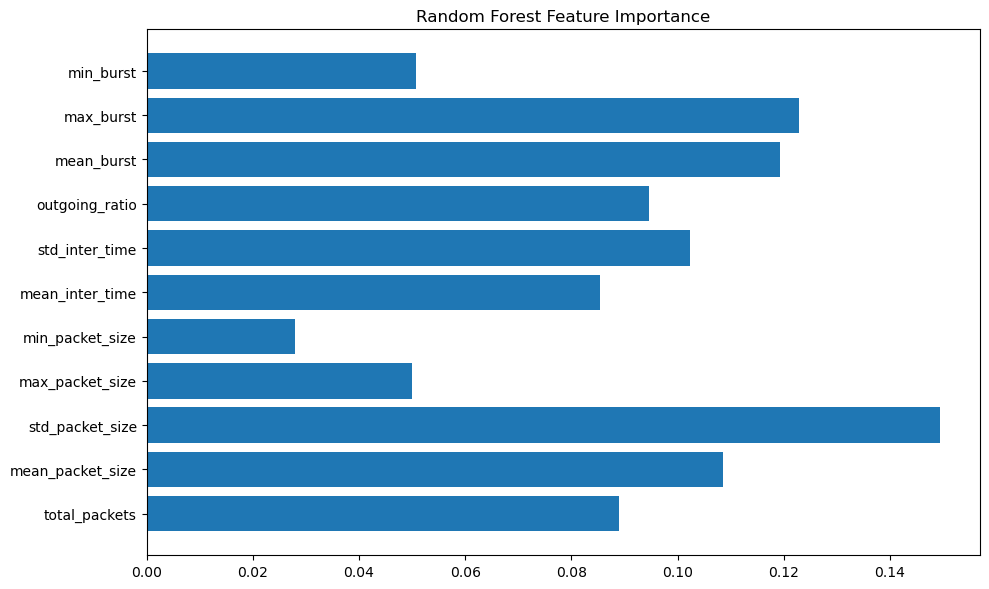

In [26]:
##Feature importance
feature_names = [
    "total_packets",
    "mean_packet_size",
    "std_packet_size",
    "max_packet_size",
    "min_packet_size",
    "mean_inter_time",
    "std_inter_time",
    "outgoing_ratio",
    "mean_burst",
    "max_burst",
    "min_burst"
]

dataset = pd.DataFrame(X, columns=feature_names)
dataset["label"] = y

importances = rf.feature_importances_
feature_names = dataset.drop("label", axis=1).columns

plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances)
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.savefig("feature_importance_rf_csv.png", dpi=300, bbox_inches='tight')
plt.show()

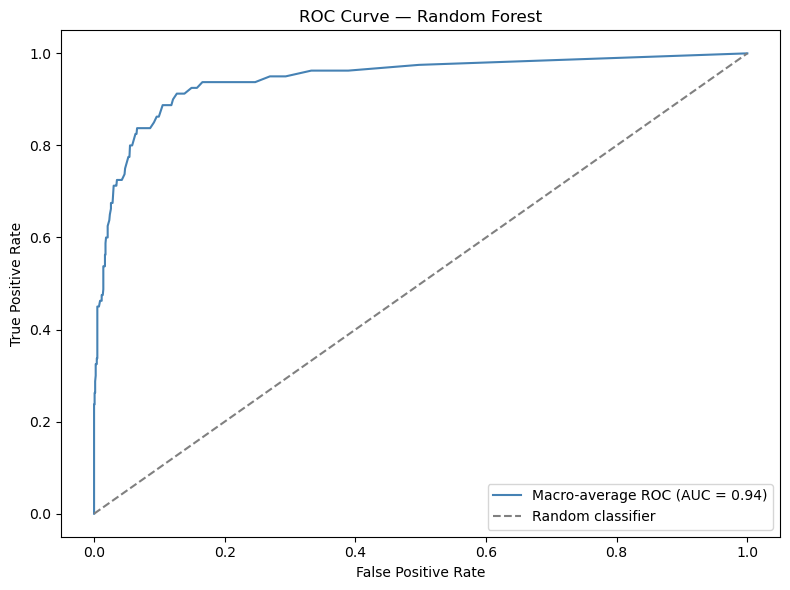

In [31]:
classes = np.unique(y)
y_bin = label_binarize(y, classes=classes)
y_pred_proba = cross_val_predict(rf, X, y, cv=5, method="predict_proba")

fpr, tpr, _ = roc_curve(y_bin.ravel(), y_pred_proba.ravel())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="steelblue", label=f"Macro-average ROC (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig("ROC_curve_rf_csv.png", dpi=300, bbox_inches='tight')
plt.show()

In [32]:
##SVM
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

svm = SVC(kernel="rbf", C=1, gamma="scale")

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, average="weighted", zero_division=0),
    "recall": make_scorer(recall_score, average="weighted", zero_division=0),
    "f1": make_scorer(f1_score, average="weighted", zero_division=0)
}

cv_results_svm = cross_validate(svm, X_scaled, y, cv=5, scoring=scoring)

print(f"Accuracy:  {cv_results_svm['test_accuracy'].mean():.4f}")
print(f"Precision: {cv_results_svm['test_precision'].mean():.4f}")
print(f"Recall:    {cv_results_svm['test_recall'].mean():.4f}")
print(f"F1-score:  {cv_results_svm['test_f1'].mean():.4f}")

Accuracy:  0.5875
Precision: 0.4875
Recall:    0.5875
F1-score:  0.5162


In [34]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1, gamma="scale"))
])

cv_results_svm = cross_validate(svm_pipeline, X, y, cv=5, scoring=scoring)

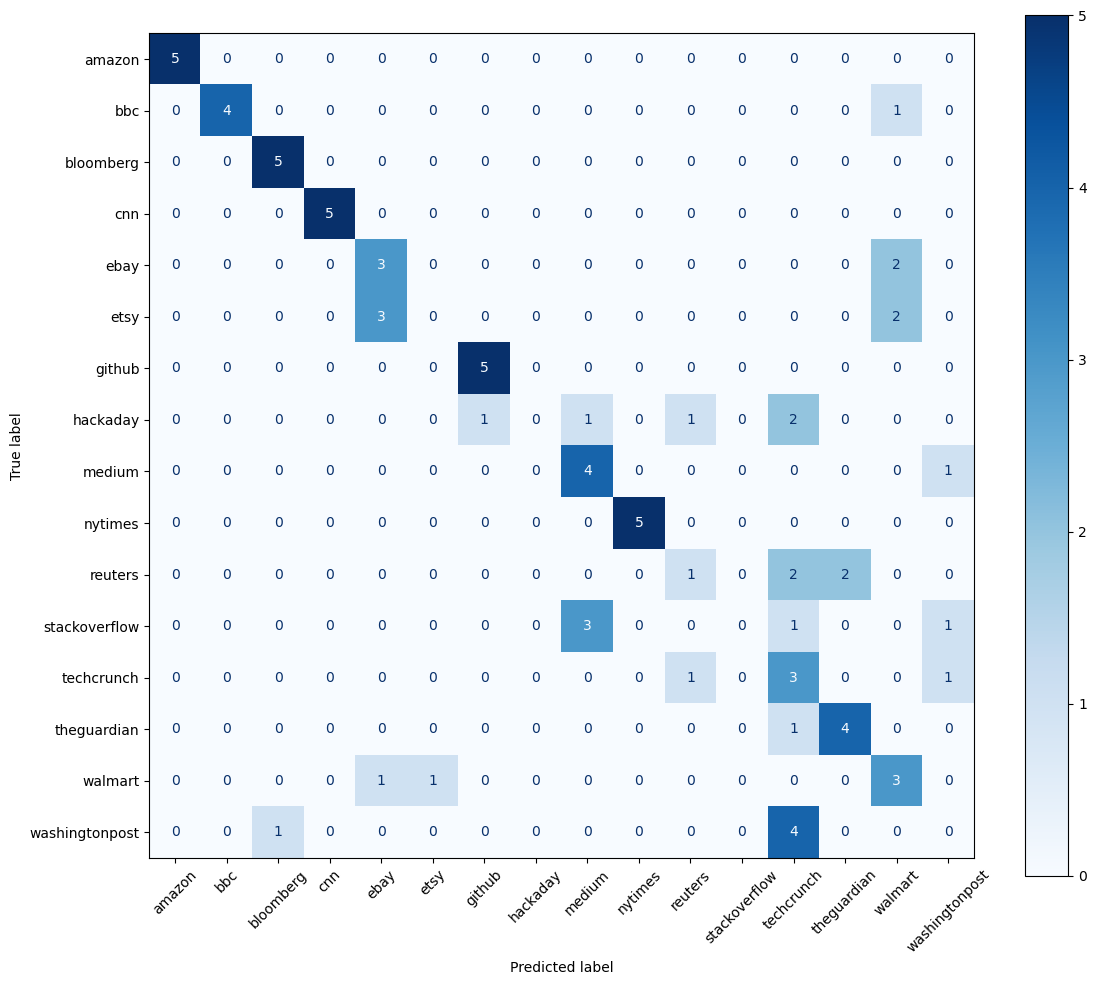

Saved: confusion_matrix_svm_csv.png


In [35]:
##SVM Confusion Matrix
y_pred_svm_cv = cross_val_predict(svm_pipeline, X, y, cv=5)

save_confusion_matrix(y, y_pred_svm_cv, np.unique(y), filename="confusion_matrix_svm_csv.png")

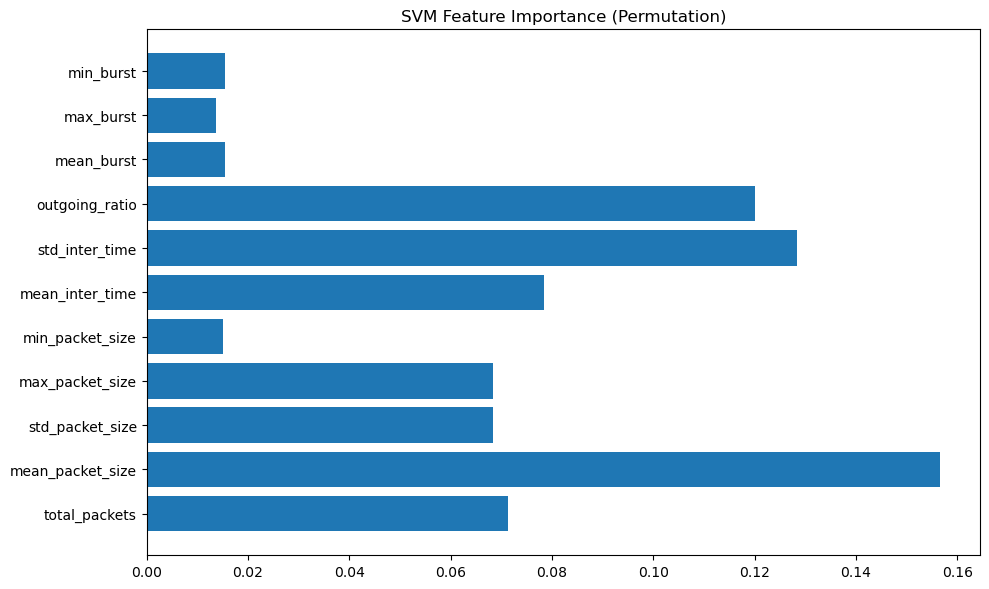

In [38]:
##Feature importance for SVM
svm_pipeline.fit(X, y)

result = permutation_importance(
    svm_pipeline, X, y,
    n_repeats=30,
    random_state=42
)

feature_names = dataset.drop("label", axis=1).columns

plt.figure(figsize=(10, 6))
plt.barh(feature_names, result.importances_mean)
plt.title("SVM Feature Importance (Permutation)")
plt.tight_layout()
plt.savefig("feature_importance_svm_csv.png", dpi=300, bbox_inches='tight')
plt.show()

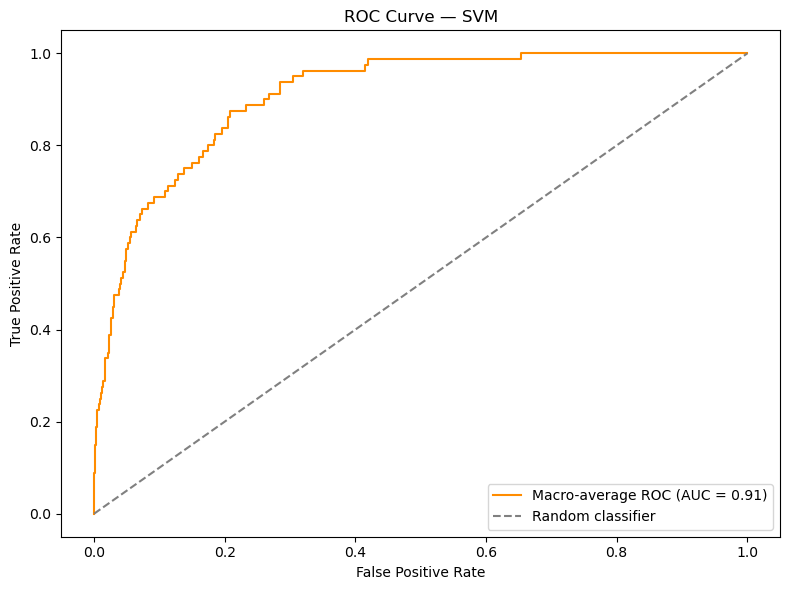

In [46]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1, gamma="scale", probability=True))
])

y_bin = label_binarize(y, classes=np.unique(y))
y_pred_svm_proba = cross_val_predict(svm_pipeline, X, y, cv=5, method="predict_proba")

fpr, tpr, _ = roc_curve(y_bin.ravel(), y_pred_svm_proba.ravel())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", label=f"Macro-average ROC (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — SVM")
plt.legend()
plt.tight_layout()
plt.savefig("ROC_curve_svm_csv.png", dpi=300, bbox_inches='tight')
plt.show()

In [62]:
##CNN reshape
X_cnn = X.astype(np.float32)

le = LabelEncoder()
y_enc = le.fit_transform(y)

num_classes = len(np.unique(y_enc))
y_cnn = to_categorical(y_enc, num_classes=num_classes)

X_train, X_test, y_train, y_test = train_test_split(
    X_cnn, y_cnn, test_size=0.2, random_state=42, stratify=y_cnn
)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [63]:
##Create the model
model = Sequential()
model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1],1)))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=30, batch_size=8, validation_split=0.2, verbose=1)

Epoch 1/30


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.0588 - loss: 1190.1711 - val_accuracy: 0.0000e+00 - val_loss: 453.6152
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0784 - loss: 565.5048 - val_accuracy: 0.0000e+00 - val_loss: 362.3257
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1176 - loss: 309.8062 - val_accuracy: 0.1538 - val_loss: 269.3628
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1765 - loss: 168.5565 - val_accuracy: 0.2308 - val_loss: 198.4253
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1373 - loss: 112.6333 - val_accuracy: 0.0769 - val_loss: 165.6773
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1765 - loss: 95.7555 - val_accuracy: 0.0769 - val_loss: 119.9098
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3137 - loss: 87.5396 - val_accuracy: 0.1538 - val_loss: 128.6925
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2549 - loss: 65.2827 - val_accuracy: 0.0000e+

In [64]:
# Accuracy
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print("CNN Accuracy:", acc)

CNN Accuracy: 0.375


In [65]:
y_pred_cnn = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_cnn, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Precision & Recall
precision = precision_score(y_true_labels, y_pred_labels, average='macro')
recall = recall_score(y_true_labels, y_pred_labels, average='macro')

print("CNN Precision (macro):", precision)
print("CNN Recall (macro):", recall)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
CNN Precision (macro): 0.18749999999999997
CNN Recall (macro): 0.375


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [66]:
cb_model_cv = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    loss_function='MultiClass',
    random_seed=42,
    verbose=False 
)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, average="weighted", zero_division=0),
    "recall": make_scorer(recall_score, average="weighted", zero_division=0),
    "f1": make_scorer(f1_score, average="weighted", zero_division=0)
}

cv_results_cb = cross_validate(cb_model_cv, X, y, cv=5, scoring=scoring)

print("\n--- CatBoost Cross-Validation Results ---")
print(f"Accuracy:  {cv_results_cb['test_accuracy'].mean():.4f}")
print(f"Precision: {cv_results_cb['test_precision'].mean():.4f}")
print(f"Recall:    {cv_results_cb['test_recall'].mean():.4f}")
print(f"F1-score:  {cv_results_cb['test_f1'].mean():.4f}")


--- CatBoost Cross-Validation Results ---
Accuracy:  0.6375
Precision: 0.5396
Recall:    0.6375
F1-score:  0.5708


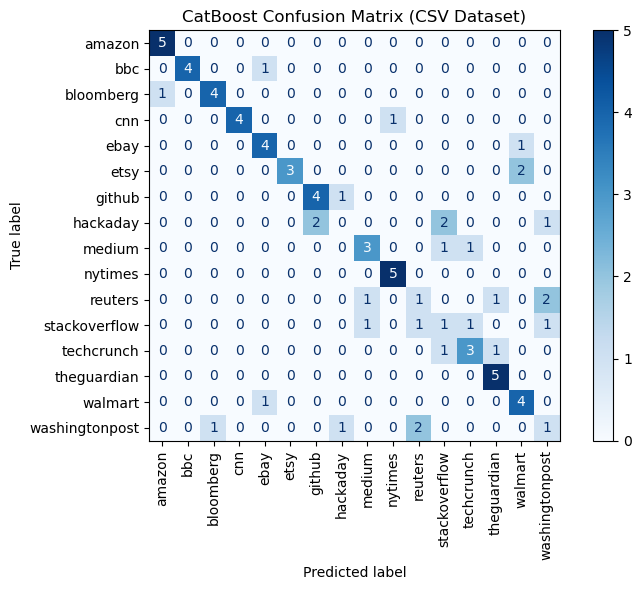

In [61]:
#Confusion Matrix
y_pred_cb = cross_val_predict(cb_model_cv, X, y, cv=5)
cm_cb = confusion_matrix(y, y_pred_cb, labels=np.unique(y))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cb, display_labels=np.unique(y))
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(
    xticks_rotation=90,
    cmap="Blues",
    ax=ax,
    colorbar=True
)
plt.title("CatBoost Confusion Matrix (CSV Dataset)")
plt.tight_layout()
plt.savefig("confusion_matrix_catboost_csv.png", dpi=300, bbox_inches='tight')
plt.show()